In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/dados_bancos_brasileiros.csv', sep =';')
df.head()

,Instituição,Código,Conglomerado Prudencial,Conglomerado Financeiro,Conglomerado Prudencial.1,TCB,TC,TI,Cidade,UF,Data,Ativo Total,Carteira de Crédito,Títulos e Valores Mobiliários,Passivo Exigível,Captações,Patrimônio Líquido,Lucro Líquido,Número de Agências,Número de Postos de Atendimento
0,BANCO DO BRASIL S.A.,0.0,BB - PRUDENCIAL,49906.0,80329.0,b1,1.0,1.0,BRASILIA,DF,mar/25,2.321.394.441,1.060.554.908,475.146.648,2.146.751.559,1.864.847.340,174.642.883,6.798.842,3.998,483
1,CAIXA ECONOMICA FEDERAL,360305.0,CAIXA ECONÔMICA FEDERAL - PRUDENCIAL,51626.0,80738.0,b1,1.0,6.0,BRASILIA,DF,mar/25,2.089.005.026,1.212.547.197,304.013.522,1.984.925.287,1.795.556.018,104.079.740,5.387.708,3.254,887
2,ITAÚ UNIBANCO S.A.,60701190.0,ITAU - PRUDENCIAL,10069.0,80099.0,b1,2.0,8.0,SAO PAULO,SP,mar/25,1.936.563.042,598.529.757,521.556.866,1.774.123.637,1.646.233.040,162.439.404,8.868.279,1.960,1.146
3,BANCO BRADESCO S.A.,60746948.0,BRADESCO - PRUDENCIAL,10045.0,80075.0,b1,2.0,8.0,OSASCO,SP,mar/25,1.622.600.238,659.086.200,255.147.506,1.458.407.420,1.273.004.563,164.192.818,5.802.082,2.300,870
4,BANCO SANTANDER (BRASIL) S.A.,90400888.0,SANTANDER - PRUDENCIAL,30379.0,80185.0,b1,3.0,8.0,SAO PAULO,SP,mar/25,1.165.249.221,357.283.264,236.920.335,1.075.235.961,926.234.202,90.013.261,3.818.044,2.387,1.544


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1672 entries, 0 to 1671
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Instituição                      1672 non-null   object 
 1   Código                           1595 non-null   float64
 2   Conglomerado Prudencial          814 non-null    object 
 3   Conglomerado Financeiro          232 non-null    float64
 4   Conglomerado Prudencial.1        815 non-null    float64
 5   TCB                              1595 non-null   object 
 6   TC                               1595 non-null   float64
 7   TI                               1595 non-null   float64
 8   Cidade                           1595 non-null   object 
 9   UF                               1595 non-null   object 
 10  Data                             1595 non-null   object 
 11  Ativo Total                      1669 non-null   object 
 12  Carteira de Crédito 

In [ ]:
colunas_financeiras = [
    'Ativo Total',
    'Carteira de Crédito',
    'Patrimônio Líquido',
    'Lucro Líquido'
]

for col in colunas_financeiras:
    df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df[df['Patrimônio Líquido'] > 0].copy()

In [ ]:
df_clean['Alavancagem'] = df_clean['Ativo Total'] / df_clean['Patrimônio Líquido']

df_clean['Exposicao_Credito'] = df_clean['Carteira de Crédito'] / df_clean['Ativo Total']

df_clean['ROE'] = df_clean['Lucro Líquido'] / df_clean['Patrimônio Líquido']

print(df_clean[['Instituição', 'Alavancagem', 'Exposicao_Credito', 'ROE']].head())

print("\n--- Informações dos Tipos de Dados ---")
print(df_clean[['Alavancagem', 'Exposicao_Credito', 'ROE']].info())

                     Instituição  Alavancagem  Exposicao_Credito       ROE
0           BANCO DO BRASIL S.A.    13.292236           0.456861  0.038930
1        CAIXA ECONOMICA FEDERAL    20.071198           0.580442  0.051765
2             ITAÚ UNIBANCO S.A.    11.921757           0.309068  0.054594
3            BANCO BRADESCO S.A.     9.882285           0.406191  0.035337
4  BANCO SANTANDER (BRASIL) S.A.    12.945306           0.306615  0.042416

--- Informações dos Tipos de Dados ---
<class 'pandas.core.frame.DataFrame'>
Index: 1580 entries, 0 to 1670
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Alavancagem        1580 non-null   float64
 1   Exposicao_Credito  1580 non-null   float64
 2   ROE                1580 non-null   float64
dtypes: float64(3)
memory usage: 49.4 KB
None


In [ ]:
colunas = ['Ativo Total', 'Carteira de Crédito', 'Patrimônio Líquido', 'Lucro Líquido']
for col in colunas:
    df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df[df['Patrimônio Líquido'] > 0].copy()
df_clean['Alavancagem'] = df_clean['Ativo Total'] / df_clean['Patrimônio Líquido']
df_clean['Exposicao_Credito'] = df_clean['Carteira de Crédito'] / df_clean['Ativo Total']
df_clean['ROE'] = df_clean['Lucro Líquido'] / df_clean['Patrimônio Líquido']

In [ ]:
features = ['Alavancagem', 'Exposicao_Credito', 'ROE']
X = df_clean[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
print("--- PERFIL DOS GRUPOS ---")

print(df_clean.groupby('Cluster')[features].mean())

print("\n--- EXEMPLOS DE CADA GRUPO ---")
for i in range(4):
    bancos = df_clean[df_clean['Cluster'] == i]['Instituição'].head(3).tolist()
    print(f"Grupo {i}: {bancos}")

--- PERFIL DOS GRUPOS ---
         Alavancagem  Exposicao_Credito        ROE
Cluster                                           
0           6.714823           0.050313  -0.013394
1           6.870737           0.606991   0.023117
2          85.472222           0.010400 -15.277778
3         837.647364           0.000000  -0.046685

--- EXEMPLOS DE CADA GRUPO ---
Grupo 0: ['ITAÚ UNIBANCO S.A.', 'BANCO SANTANDER (BRASIL) S.A.', 'BANCO BTG PACTUAL S.A.']
Grupo 1: ['BANCO DO BRASIL S.A.', 'CAIXA ECONOMICA FEDERAL', 'BANCO BRADESCO S.A.']
Grupo 2: ['MAGNUM SOCIEDADE DE CRÉDITO DIRETO S.A.']
Grupo 3: ['BANCO MASTER DE INVESTIMENTO S.A.']


In [ ]:
colunas = ['Ativo Total', 'Carteira de Crédito', 'Patrimônio Líquido', 'Lucro Líquido']
for col in colunas:
    df[col] = df[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df[df['Patrimônio Líquido'] > 0].copy()
df_clean['Alavancagem'] = df_clean['Ativo Total'] / df_clean['Patrimônio Líquido']
df_clean['Exposicao_Credito'] = df_clean['Carteira de Crédito'] / df_clean['Ativo Total']
df_clean['ROE'] = df_clean['Lucro Líquido'] / df_clean['Patrimônio Líquido']

In [ ]:
features = ['Alavancagem', 'Exposicao_Credito', 'ROE']
X = df_clean[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)


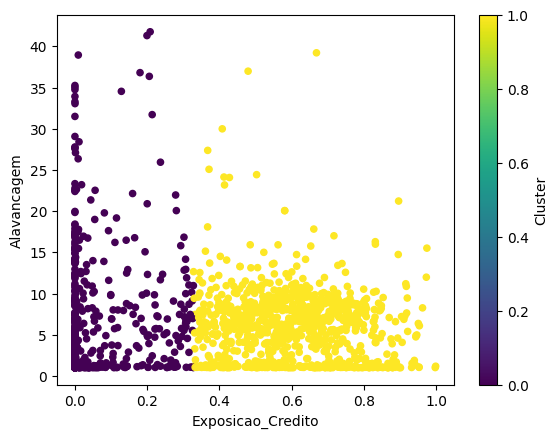

In [ ]:
df_clean[df_clean['Alavancagem'] < 50].plot.scatter(
    x='Exposicao_Credito',
    y='Alavancagem',
    c='Cluster',
    colormap='viridis'
)
plt.show()

In [ ]:
print("--- PERFIL DOS GRUPOS (Média) ---")
print(df_clean.groupby('Cluster')[features].mean())

print("\n--- EXEMPLOS TÍPICOS ---")
for i in range(4):
    bancos = df_clean[df_clean['Cluster'] == i]['Instituição'].head(3).tolist()
    print(f"Grupo {i}: {bancos}")

--- PERFIL DOS GRUPOS (Média) ---
         Alavancagem  Exposicao_Credito        ROE
Cluster                                           
0           6.714823           0.050313  -0.013394
1           6.870737           0.606991   0.023117
2          85.472222           0.010400 -15.277778
3         837.647364           0.000000  -0.046685

--- EXEMPLOS TÍPICOS ---
Grupo 0: ['ITAÚ UNIBANCO S.A.', 'BANCO SANTANDER (BRASIL) S.A.', 'BANCO BTG PACTUAL S.A.']
Grupo 1: ['BANCO DO BRASIL S.A.', 'CAIXA ECONOMICA FEDERAL', 'BANCO BRADESCO S.A.']
Grupo 2: ['MAGNUM SOCIEDADE DE CRÉDITO DIRETO S.A.']
Grupo 3: ['BANCO MASTER DE INVESTIMENTO S.A.']


In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
df_clean['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

<Figure size 1000x600 with 0 Axes>

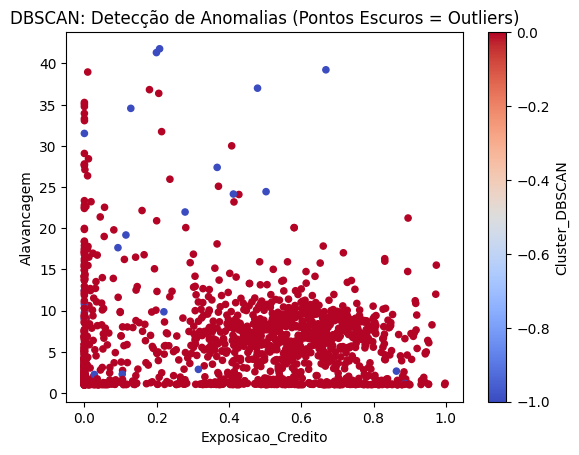

In [ ]:
plt.figure(figsize=(10, 6))
df_clean[df_clean['Alavancagem'] < 50].plot.scatter(
    x='Exposicao_Credito',
    y='Alavancagem',
    c='Cluster_DBSCAN',
    colormap='coolwarm',
    colorbar=True,
    title='DBSCAN: Detecção de Anomalias (Pontos Escuros = Outliers)'
)
plt.show()

In [ ]:
contagem = df_clean['Cluster_DBSCAN'].value_counts()
n_anomalias = contagem.get(-1, 0)
n_normais = contagem.sum() - n_anomalias

print("\n--- RESULTADO DBSCAN (Detecção de Risco) ---")
print(f"Bancos com comportamento padrão (Clusterizados): {n_normais}")
print(f"Bancos anômalos/Outliers (Código -1): {n_anomalias}")

print("\n--- QUEM SÃO AS ANOMALIAS?  ---")

print(df_clean[df_clean['Cluster_DBSCAN'] == -1]['Instituição'].head(10).tolist())


--- RESULTADO DBSCAN (Detecção de Risco) ---
Bancos com comportamento padrão (Clusterizados): 1542
Bancos anômalos/Outliers (Código -1): 38

--- QUEM SÃO AS ANOMALIAS?  ---
['BANCO COOPERATIVO SICREDI S.A.', 'BANCO BRADESCO FINANCIAMENTOS S.A.', 'BANCOSEGURO S.A.', 'BANCO ITAÚ CONSIGNADO S.A.', 'SAFRA CRÉDITO, FINANCIAMENTO E INVESTIMENTO S.A.', 'PICPAY BANK - BANCO MÚLTIPLO S.A', 'BANCO DIGIO S.A.', 'TERRA INVESTIMENTOS DISTRIBUIDORA DE TÍTULOS E VALORES MOBILIÁRIOS LTDA.', 'STONE SOCIEDADE DE CREDITO, FINANCIAMENTO E INVESTIMENTO S.A.', 'BANCO BRADESCARD S.A.']
